# Analysis of backward pass of Trident

In [1]:
import jax
import jax.numpy as jnp
import flax 
from flax import nnx

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from functools import partial
from collections import defaultdict


In [2]:
# define gaussian pdf and cdf functions
def gaussian_pdf(x: float,
                 mean: float,
                 std: float) -> float:
    """Gaussian Probability density function."""

    pd = jax.scipy.stats.norm.pdf(x=x, loc=mean, scale=std)
    return pd

def gaussian_cdf(
        x: float,
        mean: float,
        std: float
):
    "Gaussian CDF"
    cdf = jax.scipy.stats.norm.cdf(x=x, loc=mean, scale=std)
    return cdf

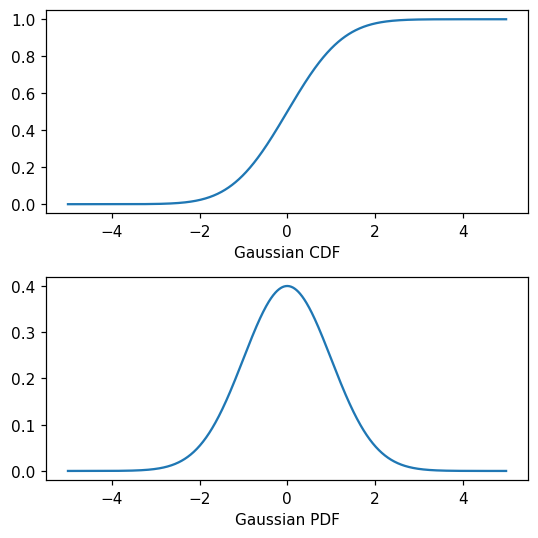

In [3]:
t = jnp.arange(-5, 5, 0.01)
mean_ = 0.0
std_ = 1
pdf_ = jax.vmap(gaussian_pdf, in_axes=(0, None, None))(t, mean_, std_)
cdf_ = jax.vmap(gaussian_cdf, in_axes=(0, None, None))(t, mean_, std_)

# preliminary plotting
fig = plt.figure(dpi=110, figsize=(5, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[0.5, 0.5], figure=fig)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

ax1.plot(t, cdf_)
ax1.set_xlabel("Gaussian CDF")
ax2.plot(t, pdf_)
ax2.set_xlabel("Gaussian PDF")



plt.tight_layout()

In [ ]:
# define the ternary activation
@jax.custom_vjp
def ternary_activation(
        x: float,
        thresholds: list[float],
        levels: list[float],
        key: jax.random.key,
        noise_std: float,
        noise_mean: float = 0.0
):
    # generate noise
    key, subkey = jax.random.split(key)
    noise = jax.random.normal(key) * noise_std + noise_mean

    # add noise to the input
    x = x + noise # mimics input referreed noise of a comparator

    # ternary activation
    s = jnp.where(
        x < thresholds[0], levels[0],
        jnp.where(
            x > thresholds[1], levels[2],
            levels[1]
        )
    )

    return s

def ternary_activation_fwd(
    x: float,
    thresholds: list[float],
    levels: list[float],
    key: jax.random.key,
    noise_std: float,
    noise_mean: float = 0.0
):
    # return the primal function in the forward mode
    y = ternary_activation(x, thresholds, levels, key, noise_std, noise_mean)
    return y, (x, thresholds, levels, key, noise_std, noise_mean) # return the primal function and the auxiliary data for the backward pass

def ternary_activation_bwd(residuals, gradients):
    # unpack the residuals
    x, thresholds, levels, key, noise_std, noise_mean = residuals

    # gradient w.r.t. x
    t_low, t_high = thresholds
    l_low, l_mid, l_high = levels # assuming that the mid-level is zero

    dx = gradients * (l_high * gaussian_pdf(x=t_high-x, mean=0, std=noise_std) - l_low * gaussian_pdf(x=t_low-x, mean=0, std=noise_std))

    # gradient w.r.t. thresholds
    dt_high = - gradients * l_high * gaussian_pdf(x=t_high-x, mean=0, std=noise_std)
    dt_low = gradients * l_low * gaussian_pdf(x=t_low-x, mean=0, std=noise_std)
    d_thresholds = jnp.array([jnp.sum(dt_low), jnp.sum(dt_high)])

    return (
        dx, # gradient w.r.t. input
        d_thresholds, # gradient w.r.t thresholds
        None, # no gradient w.r.t. levels
        None, # no gradient w,r.t. key
        None, # no gradient w.r.t. noise_std
        None # no gradient w.r.t. noise_mean
    )

# bind the forward and backward passes together
ternary_activation.defvjp(ternary_activation_fwd, ternary_activation_bwd)

def expected_state(
        x: float,
        thresholds: list[float],
        levels: list[float],
        noise_std: float,
        noise_mean: float = 0.0
):
    """Ternary expected state for gaussian input-referred noise.
    Caveat: levels[1] = 0
    """

    # compute probability for low and high states
    p_low = gaussian_cdf(x=thresholds[0] - x, mean=0, std=noise_std)
    p_high = 1 - gaussian_cdf(x=thresholds[1]-x, mean=0, std=noise_std)
    #ADD a p_mid if mid-level is not zero

    exp_state = levels[2]*p_high + levels[0]*p_low # + levels[1]*(1-p_low-p_high) if there is a non-zero mid-level
    return exp_state

    

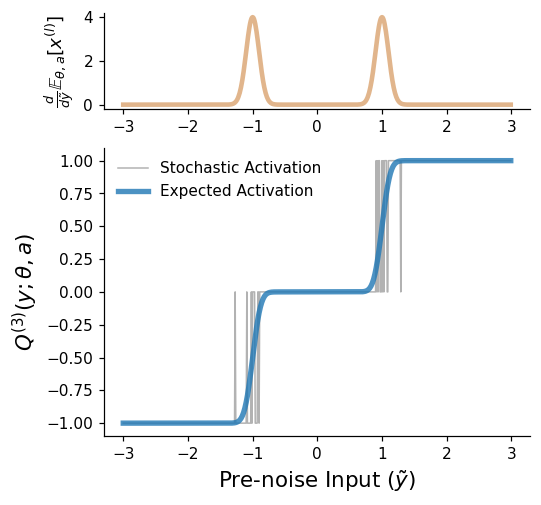

In [18]:
# plotting the ternary activation
x = jnp.arange(-3, 3, 0.01)
thresholds = jnp.array([-1., 1.])
levels = jnp.array([-1., 0., 1.])
key = jax.random.key(345)
keys = jax.random.split(key, num=x.shape[0])
noise_std = 0.1

states = jax.vmap(ternary_activation, in_axes=(0, None, None, 0, None))(x, thresholds, levels, keys, noise_std)
exp_states = jax.vmap(expected_state, in_axes=(0, None, None, None))(x, thresholds, levels, noise_std)
grad_fn = jax.grad(ternary_activation, argnums=0)
grads_ = jax.vmap(grad_fn, in_axes=(0, None, None, 0, None))(x, thresholds, levels, keys, noise_std)


# fig, ax = plt.subplots(dpi=110)
# ax.plot(x, states, alpha=.3, lw=1, c='k', label="Stochastic Activation")
# ax.plot(x, exp_states, alpha=.8, lw=3.5, label="Expected Activation")
# ax.set_xlabel("Input")
# ax.set_ylabel("Ternary Activation Output")
# ax.legend(frameon=False)

fig = plt.figure(dpi=110, figsize=(5,5))
gs = gridspec.GridSpec(2, 1, height_ratios=[0.3, 0.9], figure=fig)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax1.plot(x, grads_, c='peru', lw=3, alpha=.6)
ax1.set_ylabel(r"$\frac{d}{d\tilde{y}} \mathbb{E}_{\theta, a}[x^{(l)}]$", fontsize=12)

sns.despine(ax=ax1)

ax2.plot(x, states, alpha=.3, lw=1, c='k', label="Stochastic Activation")
ax2.plot(x, exp_states, alpha=.8, lw=3.5, label="Expected Activation")
ax2.set_xlabel(r"Pre-noise Input ($\tilde{y}$)", fontsize=14)
ax2.set_ylabel(r"$Q^{(3)}(y; \theta, a)$", fontsize=14)
ax2.legend(frameon=False)

sns.despine(ax=ax2)

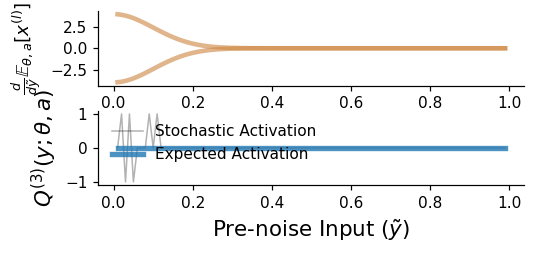

In [ ]:
# plotting gradients w.r.t. thresholds
fixed_x = 0.0
thresholds_arr = jnp.arange(0.01, 1, 0.01)
key = jax.random.key(345)
keys = jax.random.split(key, num=thresholds_arr.shape[0])
thresholds_list = jnp.array([[-l.item(), l.item()] for l in thresholds_arr])
# print(thresholds_list)
noise_std = 0.1

states = jax.vmap(ternary_activation, in_axes=(None, 0, None, 0, None))(fixed_x, thresholds_list, levels, keys, noise_std)
exp_states = jax.vmap(expected_state, in_axes=(None, 0, None, None))(fixed_x, thresholds_list, levels, noise_std)
grad_fn = jax.grad(ternary_activation, argnums=1)
grads_ = jax.vmap(grad_fn, in_axes=(None, 0, None, 0, None))(fixed_x, thresholds_list, levels, keys, noise_std)

fig, ax = plt.subplots()
